### Generate Data by Varying $\tau$ and $s$

In [1]:
# Imports
import os, sys
import numpy as np

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
from beam_problem import beam_problem as bp
from sobol import generate_sobol
from sensor_processing import sensor_processing
from yaml_processor import load_config, save_config
from data_processing import load_dataset, save_dataset

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

##### Initialization

In [2]:
# Load or Create New Data
load_init = False
load_train = False
load_val = False
load_test = False

In [3]:

T = 1/np.pi  # Time period
tau_param = (T/20, T/2) # Impulse width range
delta_s = (0.5, 0.9) # Impulse location range

param_ranges = [tau_param, delta_s]

omega = 2*np.pi/T # Omega
nt = config_global["data"]["nt"] # number of time steps
nx = config_global["data"]["nx"] # number of spatial points

n_init = 16 # number of initial full space dataset
n_train = 32 # number of initial train params
n_val = 16 # number of validation params per cluster
n_test = 128 # number of test params per cluster 

# Beam Problem
noise_std = 0.001
beam_problem = bp(nx, nt, i_range = range(1, 250), k_range = range(0, 90), vars=["tau", "s"])

##### Generate Initial Full Space Data

In [4]:
if load_init:
    SS_init, param_init, ft_init, _, _, _ = load_dataset(os.path.join(output_dir, "datasets/Init"), normalize = False)
else:
    param_init = generate_sobol(2, n_init, param_ranges)
    SS_init = np.zeros([n_init, 2, nt, nx])
    ft_init = np.zeros([n_init, nt, len(beam_problem.vars)+1])

    for i in range(n_init):
        print(f"Init - {i+1}/{n_init}")
        SS_init[i, 0], SS_init[i, 1], ft_init[i] = beam_problem.solve(tau = param_init[i, 0], s = param_init[i, 1], omega = omega)
    
    # save dataset
    save_dataset(os.path.join(output_dir, "datasets/Init"), SS_init, param_init, ft_init, cluster=None)

Init - 1/16
Init - 2/16
Init - 3/16
Init - 4/16
Init - 5/16
Init - 6/16
Init - 7/16
Init - 8/16
Init - 9/16
Init - 10/16
Init - 11/16
Init - 12/16
Init - 13/16
Init - 14/16
Init - 15/16
Init - 16/16


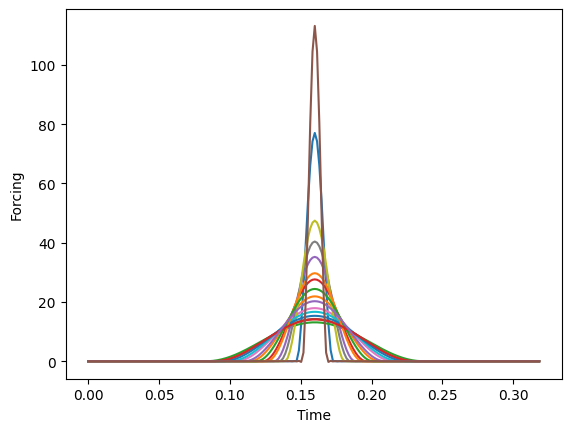

In [8]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(np.linspace(0, T, nt), ft_init[:, :, 0].T)
plt.ylabel("Forcing")
plt.xlabel("Time")
plt.show()

##### Find Optimal Sensor Locations

The preferred number of sensors is: 15


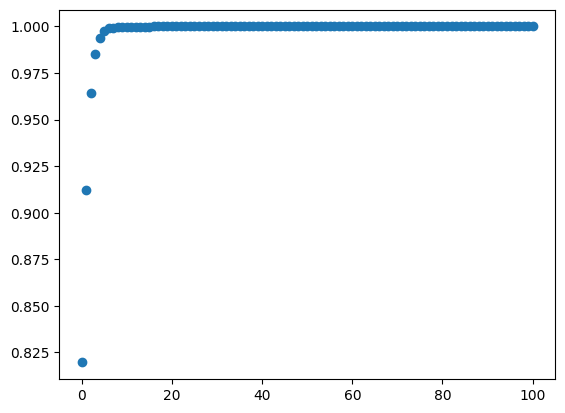

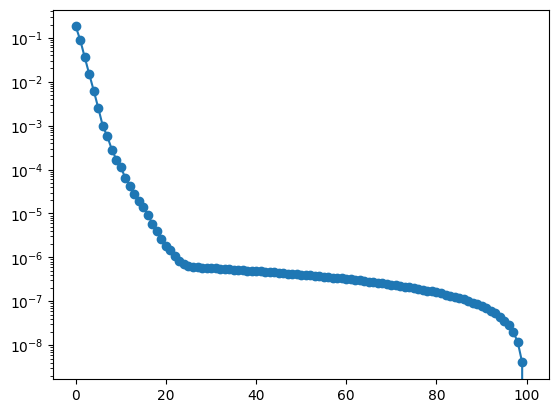

In [5]:
# Initialize sensor locator
sp = sensor_processing(SS_init[:, 1], config_global)
sp.perform_svd()
sp.plot_singular(err_cap = 0.00002)

###### Chose number of sensors

In [6]:
num_sensors = 18

In [7]:
# Apply sensor locator
sp.opt_sensor_loc(num_sensors, fill_gaps=True)
# Save setup
sp.save(output_dir)

Sensors are in [ 8 13 19 24 29 34 39 47 53 57 62 67 71 75 80 83 88 94]


In [8]:
# Save configuration
config_global["data"]["param_bounds"]["tau"] = np.sort(tau_param).tolist()
config_global["data"]["param_bounds"]["s"] = np.sort(delta_s).tolist()
config_global["sensors"]["num_sensors"] = num_sensors
save_config(config_file, config_global)

#### Generate Training Data

In [9]:
if load_train:
    SS_train, param_train = load_dataset(os.path.join(output_dir, "datasets/Train"), normalize=False)
else:
    param_train = generate_sobol(2, n_train, param_ranges)
    SS_train = np.zeros([n_train, 2, nt, nx])
    ft_train = np.zeros([n_train, nt, len(beam_problem.vars)+1])

    for i in range(n_train):
        print(f"Train - {i+1}/{n_train}")
        SS_train[i, 0], SS_train[i, 1], ft_train[i] = beam_problem.solve(tau = param_train[i, 0], s = param_train[i, 1], omega = omega)

    # save dataset
    save_dataset(os.path.join(output_dir, "datasets/Train"), SS_train, param_train, ft_train, cluster=None)

Train - 1/32
Train - 2/32
Train - 3/32
Train - 4/32
Train - 5/32
Train - 6/32
Train - 7/32
Train - 8/32
Train - 9/32
Train - 10/32
Train - 11/32
Train - 12/32
Train - 13/32
Train - 14/32
Train - 15/32
Train - 16/32
Train - 17/32
Train - 18/32
Train - 19/32
Train - 20/32
Train - 21/32
Train - 22/32
Train - 23/32
Train - 24/32
Train - 25/32
Train - 26/32
Train - 27/32
Train - 28/32
Train - 29/32
Train - 30/32
Train - 31/32
Train - 32/32


#### Generate Validation Data

In [10]:
if load_val:
    SS_val, param_val = load_dataset(os.path.join(output_dir, "datasets/Val"), normalize=False)
else:
    param_val = generate_sobol(2, n_val, param_ranges)
    SS_val = np.zeros([n_val, 2, nt, nx])
    ft_val = np.zeros([n_val, nt, len(beam_problem.vars)+1])

    for i in range(n_val):
        print(f"Val - {i+1}/{n_val}")
        SS_val[i, 0], SS_val[i, 1], ft_val[i] = beam_problem.solve(tau = param_val[i, 0], s = param_val[i, 1], omega = omega)

    # save dataset
    save_dataset(os.path.join(output_dir, "datasets/Val"), SS_val, param_val, ft_val, cluster=None)

Val - 1/16
Val - 2/16
Val - 3/16
Val - 4/16
Val - 5/16
Val - 6/16
Val - 7/16
Val - 8/16
Val - 9/16
Val - 10/16
Val - 11/16
Val - 12/16
Val - 13/16
Val - 14/16
Val - 15/16
Val - 16/16


#### Generate Testing Data

In [11]:
if load_test:
    SS_test, param_test = load_dataset(os.path.join(output_dir, "datasets/Test"), normalize=False)
else:
    param_test = generate_sobol(2, n_test, param_ranges)
    SS_test = np.zeros([n_test, 2, nt, nx])
    ft_test = np.zeros([n_test, nt, len(beam_problem.vars)+1])

    for i in range(n_test):
        print(f"Test - {i+1}/{n_test}")
        SS_test[i, 0], SS_test[i, 1], ft_test[i] = beam_problem.solve(tau = param_test[i, 0], s = param_test[i, 1], omega = omega)

    # save dataset
    save_dataset(os.path.join(output_dir, "datasets/Test"), SS_test, param_test, ft_test, cluster=None)

Test - 1/128
Test - 2/128
Test - 3/128
Test - 4/128
Test - 5/128
Test - 6/128
Test - 7/128
Test - 8/128
Test - 9/128
Test - 10/128
Test - 11/128
Test - 12/128
Test - 13/128
Test - 14/128
Test - 15/128
Test - 16/128
Test - 17/128
Test - 18/128
Test - 19/128
Test - 20/128
Test - 21/128
Test - 22/128
Test - 23/128
Test - 24/128
Test - 25/128
Test - 26/128
Test - 27/128
Test - 28/128
Test - 29/128
Test - 30/128
Test - 31/128
Test - 32/128
Test - 33/128
Test - 34/128
Test - 35/128
Test - 36/128
Test - 37/128
Test - 38/128
Test - 39/128
Test - 40/128
Test - 41/128
Test - 42/128
Test - 43/128
Test - 44/128
Test - 45/128
Test - 46/128
Test - 47/128
Test - 48/128
Test - 49/128
Test - 50/128
Test - 51/128
Test - 52/128
Test - 53/128
Test - 54/128
Test - 55/128
Test - 56/128
Test - 57/128
Test - 58/128
Test - 59/128
Test - 60/128
Test - 61/128
Test - 62/128
Test - 63/128
Test - 64/128
Test - 65/128
Test - 66/128
Test - 67/128
Test - 68/128
Test - 69/128
Test - 70/128
Test - 71/128
Test - 72/128
T